Appliquer une Analyse en composantes principales sur Iris Dataset ou wine dataset.
Les étapes sont présentes dans le cours. N’oubliez pas de plotter les histogram de
chaque variable du jeu de données utilisé

# On charge les donnees du dataset et on garde les colonnes quantitatives

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA




df = pd.read_csv("iris.csv")
print(df.head())


X = df.select_dtypes(include=[np.number]).copy()
X = X.dropna()

X


   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


# On centre et on réduit les donnees

In [3]:
scaler = StandardScaler()
z = scaler.fit_transform(X)



# On calcule toutes les composantes et on affiche les projections

In [11]:


# z : données centrées et réduites (shape n, p)
# 1. Calcul de la matrice de covariance
cov = np.cov(z, rowvar=False)

# 2. Décomposition en valeurs propres et vecteurs propres
eigvals, eigvecs = np.linalg.eigh(cov)

# 3. On trie les valeurs/vecteurs propres par ordre décroissant
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# 4. Projections des individus (scores)
scores = np.dot(z, eigvecs)

# 5. Loadings (vecteurs propres)
loadings = eigvecs

# 6. Ratio de variance expliquée
ratio = eigvals / eigvals.sum()
cum = ratio.cumsum()

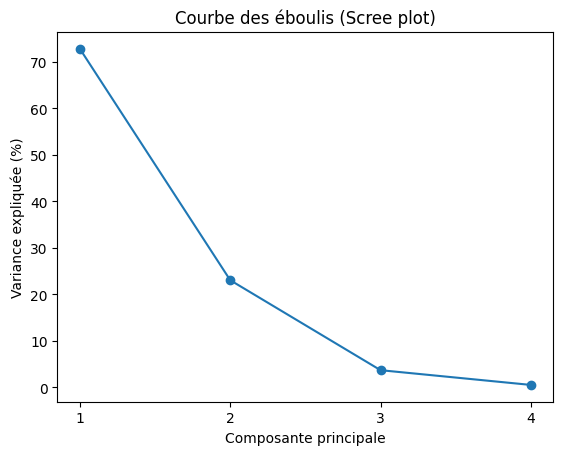

In [5]:
plt.figure()
plt.plot(range(1, len(ratio)+1), ratio*100, marker='o')
plt.xlabel("Composante principale"); plt.ylabel("Variance expliquée (%)")
plt.title("Courbe des éboulis (Scree plot)")
plt.xticks(range(1, len(ratio)+1))
plt.show()

# Remarque Courbe éboulis

La courbe des éboulis montre que la première composante principale explique une grande partie de la variance, suivie par la deuxième. À partir de la troisième composante, la variance expliquée devient très faible. Cela indique qu’il est pertinent de réduire la dimensionnalité à deux ou trois composantes principales pour conserver l’essentiel de l’information du jeu de données.

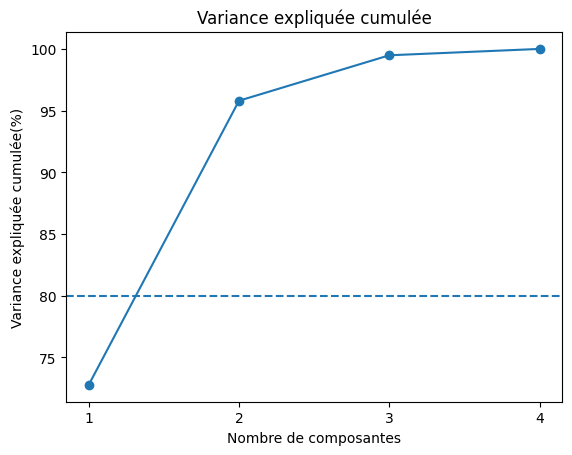

In [12]:
plt.figure()
plt.plot(range(1, len(cum)+1), cum*100, marker='o')
plt.axhline(80, linestyle='--') # exemple de seuil 80%
plt.xlabel("Nombre de composantes"); plt.ylabel("Variance expliquée cumulée(%)")
plt.title("Variance expliquée cumulée")
plt.xticks(range(1, len(cum)+1))
plt.show()

**Avec deux composantes on a déja 95% de la variance expliquée**

# Critère de Kaiser (sur corrélations ⇒ après standardisation)

In [14]:
# Matrice de corrélation (variables standardisées)
R = np.corrcoef(z, rowvar=False)
# Valeurs propres de R (R symétrique → eigh)
eigvals_R, eigvecs_R = np.linalg.eigh(R)
eigvals_R = eigvals_R[::-1] # tri décroissant
print("Valeurs propres de R :", np.round(eigvals_R, 3))
print("Nb d'axes selon Kaiser (λ>1) :", (eigvals_R > 1.0).sum())

Valeurs propres de R : [2.911 0.921 0.147 0.021]
Nb d'axes selon Kaiser (λ>1) : 1


# Biplot (PC1 vs PC2)

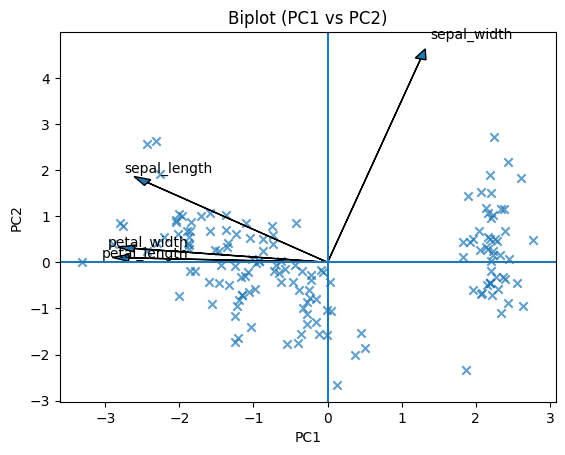

In [16]:
def biplot(scores2d, loads2d, names):
    plt.figure()
    plt.scatter(scores2d[:,0], scores2d[:,1], alpha=0.7, marker='x')
    scale = 5.0
    for i, name in enumerate(names):
        x, y = loads2d[i,0]*scale, loads2d[i,1]*scale
        plt.arrow(0, 0, x, y, head_width=0.15, length_includes_head=True)
        plt.text(x*1.05, y*1.05, name)
    plt.axhline(0); plt.axvline(0)
    plt.xlabel("PC1"); plt.ylabel("PC2"); plt.title("Biplot (PC1 vs PC2)")
    plt.show()

feature_names = X.columns
biplot(scores[:, :2], loadings[:, :2], feature_names)

# Cercle des corrélations (PC1 vs PC2)

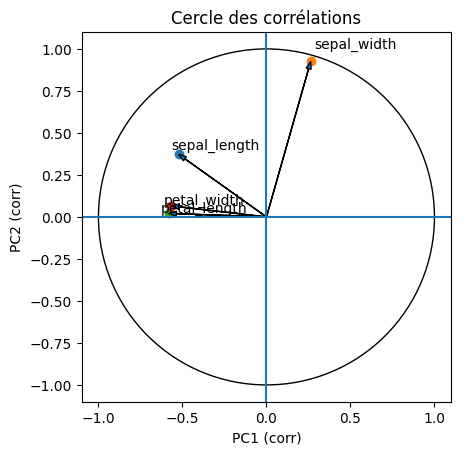

In [17]:
def correlation_circle(loads2d, names):
    plt.figure()
    ax = plt.gca()
    circle = plt.Circle((0,0), 1, fill=False)
    ax.add_artist(circle)
    for i, name in enumerate(names):
        x, y = loads2d[i,0], loads2d[i,1]
        plt.scatter(x, y)
        plt.arrow(0, 0, x, y, head_width=0.03, length_includes_head=True)
        plt.text(x*1.08, y*1.08, name)
    plt.axhline(0); plt.axvline(0)
    plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1); plt.gca().set_aspect("equal",
    "box")
    plt.xlabel("PC1 (corr)"); plt.ylabel("PC2 (corr)"); plt.title("Cercle des corrélations")
    plt.show()
correlation_circle(loadings[:, :2], feature_names)